In [ ]:
#########################################################################
###########------- Deep Learning  ------------#################
#########################################################################
# Capacitador: Julio César Bernal Fernández
# email: juliobf08@gmail.com
# Tema : Redes Neuronales Artificiales
# version: 1.0
#########################################################################

---
## **PARTE 0 - INSTALACIONES A NIVEL DE TENSORFLOW **
---

In [1]:
# Instalar KerasClassifier
!pip uninstall tensorflow

Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Would remove:
    /usr/local/bin/import_pb_to_tensorboard
    /usr/local/bin/saved_model_cli
    /usr/local/bin/tensorboard
    /usr/local/bin/tf_upgrade_v2
    /usr/local/bin/tflite_convert
    /usr/local/bin/toco
    /usr/local/lib/python3.12/dist-packages/tensorflow-2.19.0.dist-info/*
    /usr/local/lib/python3.12/dist-packages/tensorflow/*
Proceed (Y/n)? Y
  Successfully uninstalled tensorflow-2.19.0


In [2]:
!pip install -U "tensorflow==2.19.0" "keras==3.10.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.1 MB/s eta 0:00:00


In [ ]:
# !pip install tensorflow==2.12.0
# !pip install tensorflow==2.19.0

In [ ]:
# !pip install keras==2.12.0
# !pip install keras==3.10.0

In [3]:
!pip install -U "scikit-learn==1.5.2" "scikeras==0.13.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 41.7 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.11 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.41 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


---
## **PARTE I - ENTENDIMIENTO Y TRATAMIENTO DE DATOS **
---

In [4]:
# Parte 1 - Pre procesado de datos
# Cómo importar las librerías
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
%matplotlib inline

In [5]:
# Importar el data set
df = pd.read_csv('Churn_Modelling.csv')

In [6]:
# Revisamos la dimension del dataset!
df.shape

(10000, 14)

In [7]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


<Axes: xlabel='Exited', ylabel='count'>

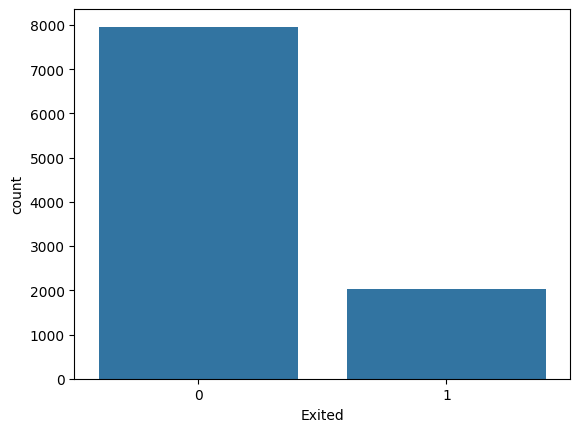

In [8]:
# Revisamos el target

sns.countplot(x='Exited',data=df)

In [9]:
# Separamos las columnas numericas y las categoricas
ColumnsCategoricas = ['Geography','Gender','HasCrCard','IsActiveMember','Exited']
ColumnsNumericas =   ['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary']

# Columnas  categoricas One Hot, Label o target Encoder!

In [10]:
# Antes de hacer cualquier trabajo con los datos, vemos los valores nulos!
df.isnull().sum()/df.shape[0]*100

,0
RowNumber,0.0
CustomerId,0.0
Surname,0.0
CreditScore,0.0
Geography,0.0
Gender,0.0
Age,0.0
Tenure,0.0
Balance,0.0
NumOfProducts,0.0


In [11]:
# Revisamos rápidamente los estadísiticos más importantes del dataset

df.describe(include='all')

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


In [12]:
# Creamos 1 dataset de variables categoricas!
df_categoricas_01 = df[ColumnsCategoricas]

In [13]:
df_categoricas_01.head(10)

,Geography,Gender,HasCrCard,IsActiveMember,Exited
0,France,Female,1,1,1
1,Spain,Female,0,1,0
2,France,Female,1,0,1
3,France,Female,0,0,0
4,Spain,Female,1,1,0
5,Spain,Male,1,0,1
6,France,Male,1,1,0
7,Germany,Female,1,0,1
8,France,Male,0,1,0
9,France,Male,1,1,0


In [14]:
# Tratamiento de Variables Categoricas
# LabelEncoder

from sklearn.preprocessing import LabelEncoder
for c in df_categoricas_01:
    print(str(c))
    le = LabelEncoder()   # 1 Instancio
    le.fit(df_categoricas_01[str(c)])
    df_categoricas_01[str(c)]=le.transform(df_categoricas_01[str(c)])

Geography
Gender
HasCrCard
IsActiveMember
Exited


/tmp/ipython-input-3519166892.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_categoricas_01[str(c)]=le.transform(df_categoricas_01[str(c)])
/tmp/ipython-input-3519166892.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_categoricas_01[str(c)]=le.transform(df_categoricas_01[str(c)])
/tmp/ipython-input-3519166892.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the document

In [15]:
# Hemos utilizado label encoder!
df_categoricas_01.head(10)

,Geography,Gender,HasCrCard,IsActiveMember,Exited
0,0,0,1,1,1
1,2,0,0,1,0
2,0,0,1,0,1
3,0,0,0,0,0
4,2,0,1,1,0
5,2,1,1,0,1
6,0,1,1,1,0
7,1,0,1,0,1
8,0,1,0,1,0
9,0,1,1,1,0


In [16]:
# Concatenamos la informacion!
df2 = pd.concat([df[ColumnsNumericas],df_categoricas_01],axis=1)

In [ ]:
# Vemos los valores del dataset!

In [17]:
df2.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Geography,Gender,HasCrCard,IsActiveMember,Exited
0,619,42,2,0.00,1,101348.88,0,0,1,1,1
1,608,41,1,83807.86,1,112542.58,2,0,0,1,0
2,502,42,8,159660.80,3,113931.57,0,0,1,0,1
3,699,39,1,0.00,2,93826.63,0,0,0,0,0
4,850,43,2,125510.82,1,79084.10,2,0,1,1,0


In [18]:
# Separamos las covariables y el target!
X = df2.iloc[:,:10]
y = df2.Exited

In [19]:
# Yo tengo 2 set de datos!
y # Target
X # Covariables!

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Geography,Gender,HasCrCard,IsActiveMember
0,619,42,2,0.00,1,101348.88,0,0,1,1
1,608,41,1,83807.86,1,112542.58,2,0,0,1
2,502,42,8,159660.80,3,113931.57,0,0,1,0
3,699,39,1,0.00,2,93826.63,0,0,0,0
4,850,43,2,125510.82,1,79084.10,2,0,1,1
...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,96270.64,0,1,1,0
9996,516,35,10,57369.61,1,101699.77,0,1,1,1
9997,709,36,7,0.00,1,42085.58,0,0,0,1
9998,772,42,3,75075.31,2,92888.52,1,1,1,0


---
## **PARTE II - PARTICION MUESTRAL  Y ESCALAMIENTO DE DATOS **
---

In [20]:
# Dividir el data set en conjunto de entrenamiento y conjunto de testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.33,random_state=111)

In [ ]:
# Numero de Hijos :       [0   - 8]     hijos
# Ingreso de la persona : [830 - 20000] soles

In [21]:
# Importante Deep Learning !!!
# Escalado de variables

from sklearn.preprocessing import StandardScaler # Importan el modulo
sc_X = StandardScaler()                          # Definir la funcion
X_train = sc_X.fit_transform(X_train)            # Ajuste
X_test = sc_X.transform(X_test)                  # Aplicacion

In [22]:
X_train

array([[ 0.09114343, -0.57035851,  0.68775758, ..., -1.08575402,
         0.64791383, -1.02447862],
       [-1.0966718 , -0.57035851,  0.34126719, ..., -1.08575402,
         0.64791383,  0.97610627],
       [ 0.70054428, -0.57035851, -0.35171361, ..., -1.08575402,
        -1.54341512, -1.02447862],
       ...,
       [-0.16707727, -1.42940083, -1.04469441, ..., -1.08575402,
         0.64791383, -1.02447862],
       [-1.03469883,  1.24317527, -0.00522321, ...,  0.92101893,
         0.64791383,  0.97610627],
       [-1.71640148, -0.66580766, -0.69820401, ..., -1.08575402,
         0.64791383,  0.97610627]])

In [23]:
X_train.shape

(6700, 10)

---
## **PARTE III - CONSTRUCCION DE LA RED NEURONAL ARTIFICIAL **
---

In [24]:
# Importar Keras y librerías adicionales
import keras
from keras.models import Sequential # Arquitectura de la red
from keras.layers import Dense      # Capas de las redes neuronales
from keras.layers import Dropout    # Regularizacion / Evita sobreajuste

In [35]:
# Inicializar la RNA.
# Si la definimos como secuencia de capas es mucho mas facil despues trabajar con ellas.
classifier = Sequential() # Podria codificar aca las capas y demas pero lo hacemos una a una.

In [26]:
X_train.shape

(6700, 10)

In [36]:
# Añadir las capas de entrada y primera capa oculta
# Dense es un tipo de capa, la necesitamos codificar.
# units : Numero de neuronas
# kernel_initializer : Inicializacion de pesos.
# activation : Funcion de activacion que te ayuda a la ingenieria de variables!
# input_dim : Es el numero de variables o X o features.
classifier.add(Dense(units = 6, kernel_initializer = "uniform",  activation = "relu", input_dim = 10)) # Primera capa oculta
#classifier.add(Dropout(p = 0.05))

In [37]:
# Añadir la segunda capa oculta
classifier.add(Dense(units = 6, kernel_initializer = "uniform",  activation = "relu"))
#classifier.add(Dropout(p = 0.01)) # Regularización

In [38]:
# Añadir la capa de salida
# Solo necesitamos una unidad pues tenemos un resultado binario.
classifier.add(Dense(units = 1, kernel_initializer = "uniform",  activation = "sigmoid"))
# Si tengo mas de 2 categorias , puedo mantener la funcion de activacion sigmoide? +1

In [39]:
# Compilar la RNA
# Podemos probar con distintos optimizadores
classifier.compile(optimizer = "adam", loss = "binary_crossentropy", metrics = ["accuracy"])

In [40]:
# Resumen de la estructura de la Red Neuronal!
classifier.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 6)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115 (460.00 B)

 Trainable params: 115 (460.00 B)

 Non-trainable params: 0 (0.00 B)

---
## **PARTE IV - ENTRENAMIENTO DE LA RED NEURONAL ARTIFICIAL **
---

In [41]:
# Ajustamos la RNA al Conjunto de Entrenamiento
# batch_size : Numero de observaciones antes de actualizar los pesos/ tamaño del bloque a procesar.
# epochs     : Numero de iteracciones globales / Mas veces mas aprendizaje u overfitting.
history = classifier.fit(X_train,
                         y_train,
                         validation_split=0.33,
                         batch_size = 32,
                         epochs = 100)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7858 - loss: 0.6745 - val_accuracy: 0.7916 - val_loss: 0.5463
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8021 - loss: 0.4943 - val_accuracy: 0.7916 - val_loss: 0.4456
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7993 - loss: 0.4367 - val_accuracy: 0.7916 - val_loss: 0.4403
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7953 - loss: 0.4254 - val_accuracy: 0.7916 - val_loss: 0.4375
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7990 - loss: 0.4245 - val_accuracy: 0.7916 - val_loss: 0.4365
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8066 - loss: 0.4218 - val_accuracy: 0.7916 - val_loss: 0.4357
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7923 - loss: 0.4359 - val_accuracy: 0.7916 - val_loss: 0.4349
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7989 - loss: 0.4245 - val_accu

In [42]:
# Evaluar el modelo y calcular predicciones finales
y_pred_train  = classifier.predict(X_train)

210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [43]:
y_pred_train


array([[0.14831275],
       [0.0772931 ],
       [0.17486401],
       ...,
       [0.03336358],
       [0.33879426],
       [0.07418701]], dtype=float32)

In [44]:
# Evaluar el modelo y calcular predicciones finales
y_pred_train  = classifier.predict(X_train)
y_pred_train = (y_pred_train>0.5)

y_pred_test  = classifier.predict(X_test)
y_pred_test = (y_pred_test>0.5)

210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [45]:
y_pred_test

array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]])

---
## **PARTE V - VALIDACION DE LA RED NEURONAL ARTIFICIAL **
---

In [46]:
# Elaborar una matriz de confusión
from sklearn.metrics import confusion_matrix,recall_score,f1_score,accuracy_score
cm_train = confusion_matrix(y_train, y_pred_train)
cm_test = confusion_matrix(y_test, y_pred_test)

recall_train = accuracy_score(y_train, y_pred_train)
recall_test = accuracy_score(y_test, y_pred_test)


print(cm_train)
print(cm_test)
print(recall_train)
print(recall_test)

[[5193  145]
 [ 930  432]]
[[2552   73]
 [ 472  203]]
0.8395522388059702
0.8348484848484848


In [ ]:
# Tarea: Hallar y comparar los siguientes indicadores: Sensibilidad, Especificidad, Precision y F1-Score

In [47]:
# GRAFICANDO resultados
# list all data in history
print(history.history.keys())


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


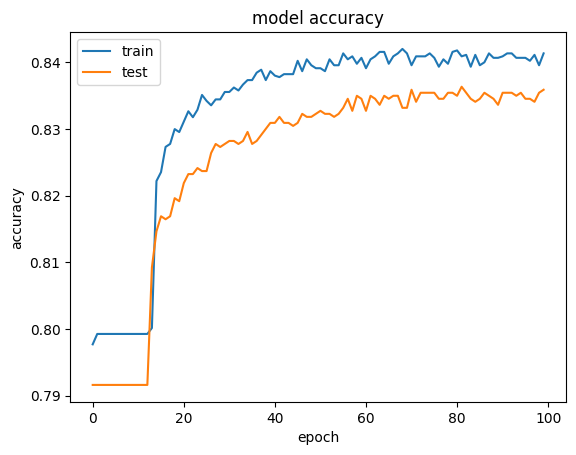

In [48]:
# Resumen del historial del accuracy!
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

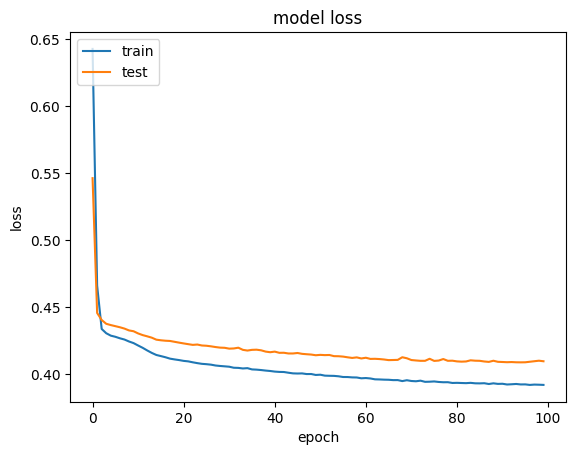

In [49]:
# Resumen del historial del error!
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [50]:
# Guardamos el modelo de red neuronal para usarlo cuando lo necesitemos!
name = 'rn_churn_modelling.h5'
classifier.save(name)

In [51]:
# Leemos el modelos con todos los pesos de la red neuronal!
new_model = keras.models.load_model(name)

In [52]:
# Mostramos la arquitectura del modelo!
new_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 6)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117 (472.00 B)

 Trainable params: 115 (460.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

---
## **PARTE VI - MEJORAR Y TUNEAR LA RED NEURONAL ARTIFICIAL **
---

In [ ]:
# Evaluar, mejorar y Ajustar la RNA

In [ ]:
# !pip install scikeras
# !pip install -U scikeras

In [53]:
### Evaluar la **RNA**
#from keras.wrappers.scikit_learn import KerasClassifier
#from sklearn.model_selection import cross_val_score
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import cross_val_score
from keras.models import Sequential
from keras.layers import Dense, Input

import keras
from keras import layers
from scikeras.wrappers import KerasClassifier

In [54]:
# Usa el Keras que ya tienes instalado (3.10)
# ⬇️ Tu modelo tal cual, pero parametrizable para el grid/random
def build_model(optimizer="adam", n_units=64, dropout=0.0):
    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),  # ajusta si tu input difiere
        layers.Dense(n_units, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid")     # binaria; cambia si es multiclase
    ])
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
    return model

# ⬇️ Wrapper sklearn-compatible (clave para evitar __sklearn_tags__)
clf = KerasClassifier(
    model=build_model,
    epochs=12,          # puedes tunear también
    batch_size=32,      # puedes tunear también
    verbose=0
)


In [ ]:
# Tiempo Ejecución: 10 minutos
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint, uniform

# === GRID SEARCH: valores discretos ===
param_grid = {
    "model__optimizer": ["adam", "sgd"],
    "model__n_units": [32, 64, 128],
    "model__dropout": [0.0, 0.3],
    "epochs": [8, 12],
    "batch_size": [32, 64],
}

grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    scoring="accuracy",   # o tu métrica
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid_search = grid_search.fit(X_train, y_train)
print("Mejor (Grid):", grid_search.best_params_, "score:", grid_search.best_score_)


Fitting 3 folds for each of 48 candidates, totalling 144 fits


In [ ]:
# Tiempo Ejecución: 4 minutos
# === RANDOMIZED SEARCH: distribuciones + n_iter ===
param_distributions = {
    "model__optimizer": ["adam", "sgd", "rmsprop"],
    "model__n_units": randint(32, 256),
    "model__dropout": uniform(0.0, 0.5),
    "epochs": randint(8, 20),
    "batch_size": [32, 64, 128],
}

random_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_distributions,
    n_iter=12,           # sube/baja según tiempo disponible
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
random_search = random_search.fit(X_train, y_train)
print("Mejor (Random):", random_search.best_params_, "score:", random_search.best_score_)

In [ ]:
# ==========================================
# Z) COMPARACIÓN FINAL: GRID vs RANDOM
#    - Requiere: grid_search y random_search ya entrenados
#    - Si existen X_test, y_test -> evalúa en test
# ==========================================
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def summarize_search(name, search):
    # Construye una fila con lo más relevante del CV
    row = {
        "busqueda": name,
        "best_score_cv": float(search.best_score_),                 # promedio CV de la métrica (p.ej., accuracy)
        "best_params": search.best_params_,                        # hiperparámetros ganadores
        "n_candidates": len(search.cv_results_["params"]),         # cuántas config probó
        "mean_fit_time_cv": float(np.mean(search.cv_results_["mean_fit_time"])),    # tiempo medio de fit por split
        "mean_score_time_cv": float(np.mean(search.cv_results_["mean_score_time"])),# tiempo medio de score por split
        "refit_time": float(getattr(search, "refit_time_", np.nan))                 # tiempo de refit al final
    }
    return row

# 1) Resumen lado a lado
rows = [
    summarize_search("GridSearchCV", grid_search),
    summarize_search("RandomizedSearchCV", random_search)
]
comp_df = pd.DataFrame(rows).sort_values("best_score_cv", ascending=False)
print("📊 Comparativa CV (mayor es mejor en 'best_score_cv'):")
display(comp_df)

# 2) Elegimos 'ganador' por CV
winner_name = comp_df.iloc[0]["busqueda"]
winner_obj = grid_search if winner_name == "GridSearchCV" else random_search
best_model = winner_obj.best_estimator_
print(f"🏆 Ganador por CV: {winner_name}")
print("🔧 Hiperparámetros ganadores:", winner_obj.best_params_)

# 3) Evaluación en test si está disponible
if "X_test" in globals() and "y_test" in globals():
    def eval_on_test(name, search):
        print(f"\n=== {name} — Evaluación en TEST ===")
        y_pred = search.best_estimator_.predict(X_test)  # SciKeras devuelve etiquetas en predict()
        acc = accuracy_score(y_test, y_pred)
        print(f"Accuracy (test): {acc:.4f}")
        try:
            print("\nClassification report:")
            print(classification_report(y_test, y_pred, digits=4))
        except Exception as e:
            print("No se pudo imprimir classification_report:", e)
        try:
            print("Matriz de confusión:")
            print(confusion_matrix(y_test, y_pred))
        except Exception as e:
            print("No se pudo imprimir la matriz de confusión:", e)

    eval_on_test("GridSearchCV", grid_search)
    eval_on_test("RandomizedSearchCV", random_search)
else:
    print("\n⚠️ No se detectó X_test/y_test en el entorno; se muestran sólo métricas de validación cruzada (CV).")

# 4) (Opcional) Si quieres guardar el mejor modelo final:
# best_model (winner_obj.best_estimator_) es tu estimator listo para .predict()
# Para Keras/SciKeras:
#   - Puedes acceder al modelo Keras subyacente con: best_model.model_ (una vez entrenado)
#   - Ejemplo para guardar:
# try:
#     best_model.model_.save("/content/mejor_modelo_keras.keras")
#     print("💾 Modelo Keras guardado en /content/mejor_modelo_keras.keras")
# except Exception as e:
#     print("No se pudo guardar el modelo Keras:", e)


In [ ]:
# FIN !!